# Librerias a utilizar

In [1]:
from keras.layers import Input, Conv2D, Flatten, Dense, Conv2DTranspose, Reshape, Lambda, Dropout, BatchNormalization, UpSampling2D, LeakyReLU
from keras.models import Model
from keras import backend as K
from keras.optimizers import Adam, RMSprop
from keras.losses import binary_crossentropy
from keras.callbacks import ModelCheckpoint 

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import glob

2025-02-16 23:07:56.900416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739765277.037134   13245 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739765277.074865   13245 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-16 23:07:57.438100: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
!wget https://raw.githubusercontent.com/zaidalyafeai/QuickDraw10/master/quick_draw10.py



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://raw.githubusercontent.]87quick_draw10.py      100% [=============================>]    1.28K    --.-KB/s87[Files: 1  Bytes: 1.28K [3.09KB]8

In [3]:
from quick_draw10 import download_and_load, plot_tsne

x_train, y_train, x_test, y_test, class_names = download_and_load()

print(class_names)

downloading ...
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cloud.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/sun.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pants.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/umbrella.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/table.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/ladder.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/eyeglasses.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/clock.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/scissors.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cup.npy
loading ...
Training Data :  80000
Testing  Data :  20000
['cloud', 'sun', 'pants', 'umbrella', 'table', 'ladder', 'eyeglasses', 'clock', 'scissors', 'cup']


#  Observar el dataset Calaveras de Quick, Draw! The Data

In [4]:
# Seleccionar un objeto

objeto = []

for i in range (len(x_train)):
  if y_train[i] == 8:
    objeto.append(x_train[i])

print('Numero de objetos: ', len(objeto), 'forma: ', np.asarray(objeto).shape)

Numero de objetos:  8034 forma:  (8034, 28, 28)


In [5]:
#Ver algunos ejemplos de las imagenes

# Completar toda esta seccion

plt.show()

# Generar el modelo de GAN

In [6]:
# Definir el modelo del variational autoencoder
input_size = (28,28,1)
latent_dim = 100
d_p = 0.3

#Discriminador
x = Input(input_size)
conv1 = Conv2D(64,5,strides=(2,2),padding='same',activation=LeakyReLU(alpha=0.2))(x)
conv1 = Dropout(d_p)(conv1)
#conv1 = BatchNormalization()(conv1)
conv2 = Conv2D(64,5,strides=(2,2),padding='same',activation=LeakyReLU(alpha=0.2))(conv1)
conv2 = Dropout(d_p)(conv2)
#conv2 = BatchNormalization()(conv2)
conv3 = Conv2D(128,5,strides=(2,2),padding='same',activation=LeakyReLU(alpha=0.2))(conv2)
conv3 = Dropout(d_p)(conv3)
#conv3 = BatchNormalization()(conv3)
conv4 = Conv2D(128,5,strides=(1,1),padding='same',activation=LeakyReLU(alpha=0.2))(conv3)
conv4 = Dropout(d_p)(conv4)
#conv4 = BatchNormalization()(conv4)
f = Flatten()(conv4)
d1 = Dense(1, activation='sigmoid')(f)



#Generador
g_x = Input(shape=(latent_dim,))
d = Dense(3136)(g_x)
d = BatchNormalization()(d)
r = Reshape((7,7,64))(d)

dec1 = UpSampling2D(size=(2,2))(r)
dec1 = Conv2D(128,5,strides=(1,1), padding='same', activation=LeakyReLU(alpha=0.2))(dec1)
dec1 = BatchNormalization(momentum=0.8)(dec1)

dec2 = UpSampling2D(size=(2,2))(dec1)
dec2 = Conv2D(64,5,strides=(1,1), padding='same', activation=LeakyReLU(alpha=0.2))(dec2)
dec2 = BatchNormalization(momentum=0.8)(dec2)

dec3 = Conv2D(64,5,strides=(1,1), padding='same', activation=LeakyReLU(alpha=0.2))(dec2)
dec3 = BatchNormalization(momentum=0.8)(dec3)

dec4 = Conv2D(1,5,strides=(1,1), padding='same', activation='tanh')(dec3) #sigmoid

/home/edgarrt/.local/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
I0000 00:00:1739765343.706212   13245 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [7]:
# Compilar los modelos

opti = Adam(0.0002, 0.5)

# Definir discriminador y generador
discriminador = Model(x, d1, name= 'discriminador')
discriminador.compile(optimizer=opti, loss='binary_crossentropy', metrics=['accuracy'])
discriminador.summary()

generador = Model(g_x, dec4, name='generador')
generador.summary()

# Modelo combinado
discriminador.trainable = False
opti_t = Adam(0.0002, 0.5)
sal_dis = discriminador(generador(g_x))
modelo_t = Model(g_x, sal_dis)
modelo_t.compile(optimizer=opti_t, loss='binary_crossentropy', metrics=['accuracy'])
modelo_t.summary()

Model: "discriminador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 720,833 (2.75 MB)

 Trainable params: 720,833 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generador (Functional)          │ (None, 28, 28, 1)      │       844,161 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminador (Functional)      │ (None, 1)              │       720,833 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,564,994 (5.97 MB)

 Trainable params: 837,377 (3.19 MB)

 Non-trainable params: 727,617 (2.78 MB)

In [8]:
# Se necesita entrenar en dos partes

# Primero el discriminador para que diferencia imagenes reales de ruido

# Con ayuda del discriminador se entrena el generador
def train(epochs, batch_size=128, sample_interval=50):#
        X_train= np.array(objeto)
        X_train = X_train / 127.5 - 1.
        X_train = np.expand_dims(X_train, axis=-1)

        valid = np.ones((batch_size, 1))   # Tomar los valores como reales
        fake = np.zeros((batch_size, 1))   # Tomar los valores como falsos

        for epoch in range(epochs):
            idx = np.random.randint(0, X_train.shape[0], batch_size) # Escoje numero aleatoriamente
            imgs = X_train[idx]                                      # Toma idx imagenes reales

            noise = np.random.normal(0, 1, (batch_size, latent_dim)) # crea ruidos aleatorios
            
            gen_imgs = generador.predict(noise)                      # Crea objetos falsos

            discriminador.trainable = True
            d_loss_fake = discriminador.train_on_batch(gen_imgs, fake) # Observa los objetos falsos
            d_loss_real = discriminador.train_on_batch(imgs, valid)  # Observa los objetos reales
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)            # Junta las dos perdidas del discriminador

            discriminador.trainable = False
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            g_loss = modelo_t.train_on_batch(noise, valid)           # Observa la perdida del modelo total

            print ('Epoca: ',epoch, '  D_loss: ', np.round(d_loss[0],3), '  G_loss: ', np.round(g_loss[0],3), '  D_loss_real: ', np.round(d_loss_real[0],3))
            if epoch % sample_interval == 0:
              sample_images(epoch)

def sample_images(epoch):
        r, c = 5, 5
        noise = np.random.normal(0, 1, (r * c, latent_dim))
        gen_imgs = generador.predict(noise)
        gen_imgs = 0.5 * gen_imgs + 0.5
        fig, axs = plt.subplots(r, c)
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i, j].imshow(gen_imgs[cnt, :, :, 0], cmap='gray')
                axs[i, j].axis('off')
                cnt += 1
        plt.show()



# Entrenar y probar el generador

I0000 00:00:1739765345.579928   13338 service.cc:148] XLA service 0x7f8d2c0034a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739765345.580332   13338 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-02-16 23:09:05.627470: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1739765345.706886   13338 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-02-16 23:09:06.015756: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,128,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,14,14]{3,2,1,0}, f32[128,64,5,5]{3,2,1,0}, f32[128]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


I0000 00:00:1739765347.318612   13338 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-02-16 23:09:20.633329: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[64,128,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,14,14]{3,2,1,0}, f32[128,64,5,5]{3,2,1,0}, f32[128]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-02-16 23:09:21.004881: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[64,64,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128

Epoca:  0   D_loss:  0.699   G_loss:  0.705   D_loss_real:  0.705


2025-02-16 23:09:28.050255: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[25,128,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[25,64,14,14]{3,2,1,0}, f32[128,64,5,5]{3,2,1,0}, f32[128]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-02-16 23:09:28.166122: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[25,64,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[25,128,28,28]{3,2,1,0}, f32[64,128,5,5]{3,2,1,0}, f32[64]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActi

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


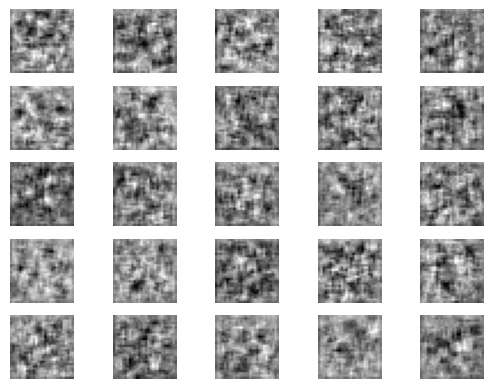

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  1   D_loss:  0.693   G_loss:  0.684   D_loss_real:  0.684
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Epoca:  2   D_loss:  0.675   G_loss:  0.662   D_loss_real:  0.662
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Epoca:  3   D_loss:  0.649   G_loss:  0.632   D_loss_real:  0.632
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoca:  4   D_loss:  0.605   G_loss:  0.584   D_loss_real:  0.584
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  5   D_loss:  0.533   G_loss:  0.513   D_loss_real:  0.513
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  6   D_loss:  0.459   G_loss:  0.443   D_loss_real:  0.443
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  7   D_loss:  0.402   G_loss:  0.391   D_loss_real:  0.391
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  8   D_loss:  0.365   G_loss:  0.355   D_loss_real:  0.355
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  9   D_loss:  0.328   G_loss:  0.32   D_loss_real:  0.32
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  10   D_loss:  0.298 

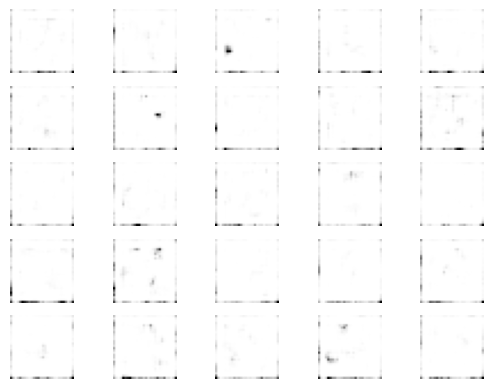

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoca:  101   D_loss:  0.075   G_loss:  0.075   D_loss_real:  0.075
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  102   D_loss:  0.074   G_loss:  0.074   D_loss_real:  0.074
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  103   D_loss:  0.074   G_loss:  0.073   D_loss_real:  0.073
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  104   D_loss:  0.073   G_loss:  0.073   D_loss_real:  0.073
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  105   D_loss:  0.072   G_loss:  0.072   D_loss_real:  0.072
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  106   D_loss:  0.072   G_loss:  0.072   D_loss_real:  0.072
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  107   D_loss:  0.071   G_loss:  0.071   D_loss_real:  0.071
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Epoca:  108   D_loss:  0.07   G_loss:  0.07   D_loss_real:  0.07
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  109   D_loss:  0.07   G_loss:  0.07   D_loss_real:  0.07
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Epoca:  110   

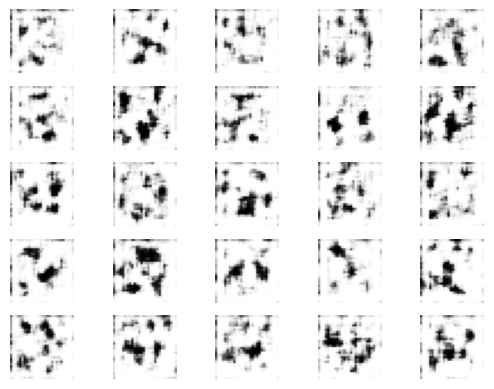

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  201   D_loss:  0.075   G_loss:  0.075   D_loss_real:  0.075
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  202   D_loss:  0.076   G_loss:  0.076   D_loss_real:  0.076
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoca:  203   D_loss:  0.076   G_loss:  0.077   D_loss_real:  0.077
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  204   D_loss:  0.077   G_loss:  0.077   D_loss_real:  0.077
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  205   D_loss:  0.078   G_loss:  0.079   D_loss_real:  0.079
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  206   D_loss:  0.08   G_loss:  0.08   D_loss_real:  0.08
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoca:  207   D_loss:  0.082   G_loss:  0.082   D_loss_real:  0.082
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoca:  208   D_loss:  0.087   G_loss:  0.088   D_loss_real:  0.088
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  209   D_loss:  0.089   G_loss:  0.089   D_loss_real:  0.089
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  210

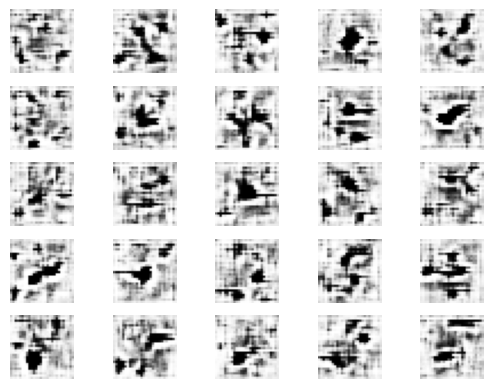

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  301   D_loss:  0.182   G_loss:  0.183   D_loss_real:  0.183
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  302   D_loss:  0.184   G_loss:  0.184   D_loss_real:  0.184
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Epoca:  303   D_loss:  0.185   G_loss:  0.185   D_loss_real:  0.185
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  304   D_loss:  0.187   G_loss:  0.187   D_loss_real:  0.187
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  305   D_loss:  0.189   G_loss:  0.189   D_loss_real:  0.189
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  306   D_loss:  0.19   G_loss:  0.191   D_loss_real:  0.191
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  307   D_loss:  0.192   G_loss:  0.192   D_loss_real:  0.192
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  308   D_loss:  0.193   G_loss:  0.193   D_loss_real:  0.193
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoca:  309   D_loss:  0.194   G_loss:  0.194   D_loss_real:  0.194
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Epoca:  3

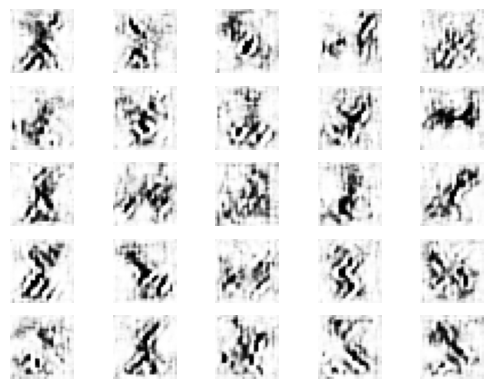

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoca:  401   D_loss:  0.3   G_loss:  0.3   D_loss_real:  0.3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  402   D_loss:  0.301   G_loss:  0.301   D_loss_real:  0.301
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  403   D_loss:  0.302   G_loss:  0.302   D_loss_real:  0.302
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  404   D_loss:  0.303   G_loss:  0.303   D_loss_real:  0.303
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoca:  405   D_loss:  0.304   G_loss:  0.304   D_loss_real:  0.304
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  406   D_loss:  0.305   G_loss:  0.305   D_loss_real:  0.305
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  407   D_loss:  0.306   G_loss:  0.306   D_loss_real:  0.306
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  408   D_loss:  0.307   G_loss:  0.307   D_loss_real:  0.307
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  409   D_loss:  0.308   G_loss:  0.308   D_loss_real:  0.308
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  410   

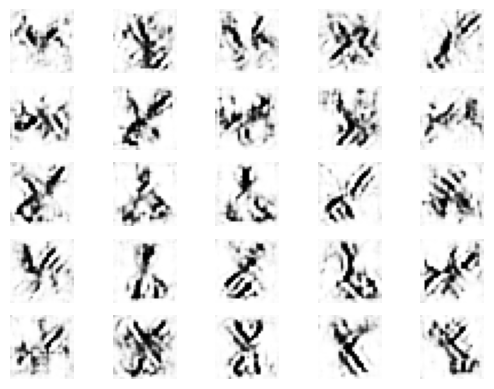

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  501   D_loss:  0.376   G_loss:  0.376   D_loss_real:  0.376
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  502   D_loss:  0.377   G_loss:  0.377   D_loss_real:  0.377
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  503   D_loss:  0.377   G_loss:  0.377   D_loss_real:  0.377
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  504   D_loss:  0.378   G_loss:  0.378   D_loss_real:  0.378
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoca:  505   D_loss:  0.378   G_loss:  0.379   D_loss_real:  0.379
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  506   D_loss:  0.379   G_loss:  0.379   D_loss_real:  0.379
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  507   D_loss:  0.38   G_loss:  0.38   D_loss_real:  0.38
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoca:  508   D_loss:  0.38   G_loss:  0.38   D_loss_real:  0.38
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  509   D_loss:  0.381   G_loss:  0.381   D_loss_real:  0.381
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  510   

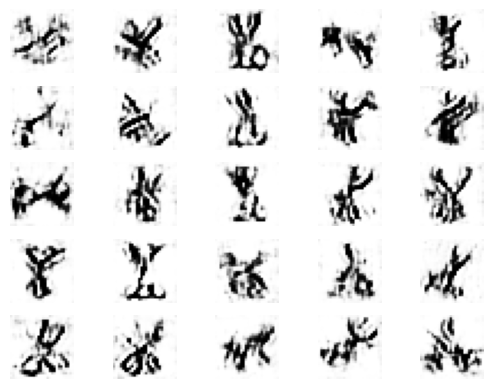

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoca:  601   D_loss:  0.426   G_loss:  0.426   D_loss_real:  0.426
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  602   D_loss:  0.427   G_loss:  0.427   D_loss_real:  0.427
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  603   D_loss:  0.427   G_loss:  0.427   D_loss_real:  0.427
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epoca:  604   D_loss:  0.428   G_loss:  0.428   D_loss_real:  0.428
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  605   D_loss:  0.428   G_loss:  0.428   D_loss_real:  0.428
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Epoca:  606   D_loss:  0.428   G_loss:  0.429   D_loss_real:  0.429
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  607   D_loss:  0.429   G_loss:  0.429   D_loss_real:  0.429
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  608   D_loss:  0.429   G_loss:  0.429   D_loss_real:  0.429
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoca:  609   D_loss:  0.43   G_loss:  0.43   D_loss_real:  0.43
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Epoca:  610

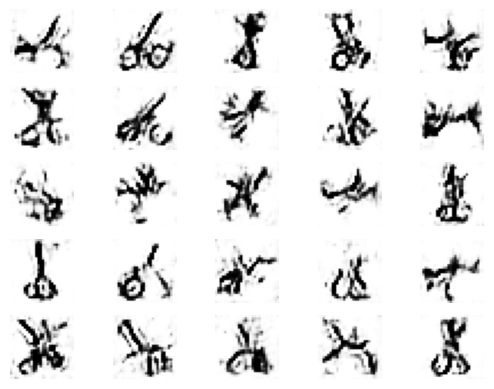

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Epoca:  701   D_loss:  0.463   G_loss:  0.463   D_loss_real:  0.463
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  702   D_loss:  0.463   G_loss:  0.463   D_loss_real:  0.463
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  703   D_loss:  0.463   G_loss:  0.463   D_loss_real:  0.463
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Epoca:  704   D_loss:  0.463   G_loss:  0.464   D_loss_real:  0.464
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  705   D_loss:  0.464   G_loss:  0.464   D_loss_real:  0.464
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoca:  706   D_loss:  0.464   G_loss:  0.464   D_loss_real:  0.464
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoca:  707   D_loss:  0.464   G_loss:  0.464   D_loss_real:  0.464
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  708   D_loss:  0.465   G_loss:  0.465   D_loss_real:  0.465
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Epoca:  709   D_loss:  0.465   G_loss:  0.465   D_loss_real:  0.465
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  

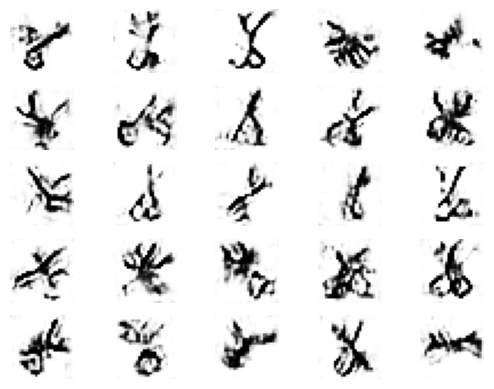

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Epoca:  801   D_loss:  0.489   G_loss:  0.489   D_loss_real:  0.489
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Epoca:  802   D_loss:  0.49   G_loss:  0.49   D_loss_real:  0.49
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoca:  803   D_loss:  0.49   G_loss:  0.49   D_loss_real:  0.49
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  804   D_loss:  0.49   G_loss:  0.49   D_loss_real:  0.49
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  805   D_loss:  0.49   G_loss:  0.49   D_loss_real:  0.49
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Epoca:  806   D_loss:  0.49   G_loss:  0.49   D_loss_real:  0.49
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Epoca:  807   D_loss:  0.491   G_loss:  0.491   D_loss_real:  0.491
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoca:  808   D_loss:  0.491   G_loss:  0.491   D_loss_real:  0.491
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Epoca:  809   D_loss:  0.491   G_loss:  0.491   D_loss_real:  0.491
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoca:  810   D_loss:  

In [ ]:
train(epochs=8000, batch_size=64, sample_interval=100)

In [ ]:
# probar el modelo terminado

sample_images(epoch=2000)